# 01 · Exploratory Data Analysis — Multi-LexSum

In [1]:
import sys, os, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_colwidth", 120)
import config as C
DF = pd.read_parquet(C.SUBSET_PARQUET)
print("Loaded subset:", DF.shape)
DF.head(2)


Loaded subset: (1915, 16)


,case_id,case_name,split,case_type,class_action_sought,court,state,filing_year,n_documents,n_clean_chars,full_text_raw,full_text_clean,summary_long,summary_short,summary_tiny,case_url
0,NS-NY-0008,ACLU v. FBI,train,National Security,No,Southern District of New York,New York,2011,7,115802,Case 1:11-cv-07562-WHP Document 1 Filed 10/26/11 Page 1 of 11\n\n0 UNITED STATES DISTRIC\n\nRT\n\n% SOUTHERN DISTRIC...,0 UNITED STATES DISTRIC\n\nRT\n\n% SOUTHERN DISTRICT OF NEW\n\nAMERICAN CIVIL LIBERTIES UNION 125 Broad Street New Y...,"On October 26, 2011, the ACLU filed a lawsuit in the U.S. District Court for the Southern District of New York again...","On October 26, 2011, the ACLU filed a lawsuit to compel the government to comply with a Freedom of Information Act r...",ACLU lawsuit versus FBI and Department of Justice results in the release of thousands of pages of documents related ...,https://clearinghouse.net/case/13769
1,FA-HI-0001,Hawaii Defense Foundation v. City and County of Honolulu,train,Speech and Religious Freedom,No,District of Hawaii,Hawaii,2012,5,117062,Case: 1:12-cv-00469-JMS-RLP As of: 01/23/2019 12:27 PM HST 1 of 10\nU.S. District Court District of Hawaii (Hawaii) ...,Case: 1:12-cv-00469-JMS-RLP As of: 01/23/2019 12:27 PM HST 1 of 10\nU.S. District Court District of Hawaii (Hawaii) ...,"On August 12, 2012, the Hawaii Defense Foundation and two of its members filed this lawsuit in the U.S. District Cou...","In 2012, the Hawaii Defense Foundation filed this complaint in the U.S. District Court for the District of Hawaii. P...",Lawsuit by the Hawaii Defense Foundation lead to private settlement and attorneys' fees (D. Haw.),https://clearinghouse.net/case/16977


## 1. What is in each column?
Every row is one civil-rights case: the full (cleaned) text of all its court documents, three expert reference summaries, and metadata including the two modelling targets `class_action_sought` and `case_type`.

In [2]:
DF.dtypes


case_id                object
case_name              object
split                  object
case_type              object
class_action_sought    object
court                  object
state                  object
filing_year            object
n_documents             int64
n_clean_chars           int64
full_text_raw          object
full_text_clean        object
summary_long           object
summary_short          object
summary_tiny           object
case_url               object
dtype: object

In [3]:
DF[["case_id","case_name","case_type","class_action_sought","n_documents","n_clean_chars","split"]].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,1915,1915,PC-ME-0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
case_name,1915,1890,Electronic Frontier Foundation v. Department of Justice,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
case_type,1915,12,Prison Conditions,180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class_action_sought,1915,2,No,1189,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_documents,1915.0,NaN,NaN,NaN,9.172324,9.15931,1.0,4.0,6.0,11.0,122.0
n_clean_chars,1915.0,NaN,NaN,NaN,100596.390601,29712.256254,5821.0,96867.5,115826.0,117906.0,125670.0
split,1915,3,train,1340,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Split sizes & target distributions

In [4]:
print("Split sizes:\n", DF.split.value_counts(), "\n")
print("class_action_sought:\n", DF.class_action_sought.value_counts())

Split sizes:
 split
train    1340
test      381
dev       194
Name: count, dtype: int64 

class_action_sought:
 class_action_sought
No     1189
Yes     726
Name: count, dtype: int64


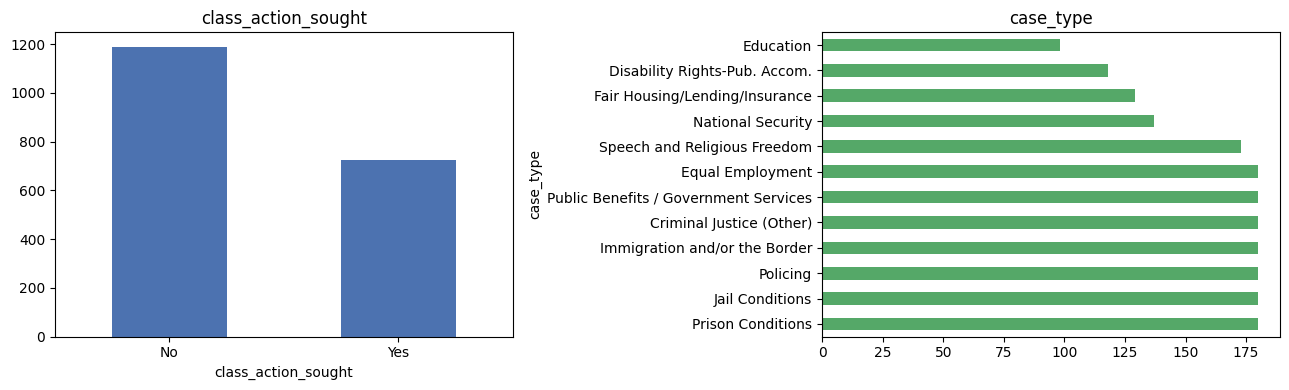

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13,4))
DF.class_action_sought.value_counts().plot.bar(ax=ax[0], color="#4C72B0")
ax[0].set_title("class_action_sought"); ax[0].tick_params(axis="x", rotation=0)
DF.case_type.value_counts().plot.barh(ax=ax[1], color="#55A868")
ax[1].set_title("case_type"); plt.tight_layout(); plt.show()

## 3. Document length
Legal cases are long — even after capping each case at 120k chars the median case is ~100k characters spread over several documents.

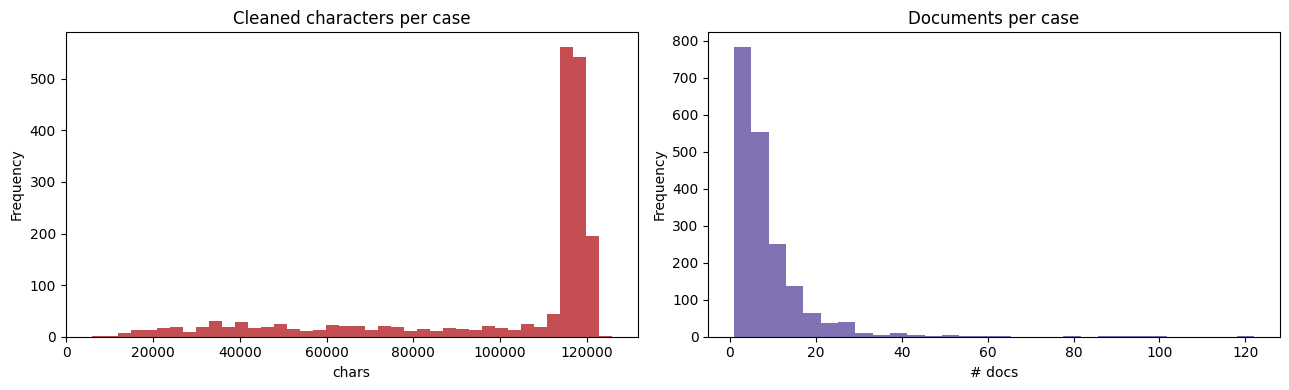

,count,mean,std,min,25%,50%,75%,max
n_clean_chars,1915.0,100596.390601,29712.256254,5821.0,96867.5,115826.0,117906.0,125670.0
n_documents,1915.0,9.172324,9.159310,1.0,4.0,6.0,11.0,122.0


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13,4))
DF.n_clean_chars.plot.hist(bins=40, ax=ax[0], color="#C44E52")
ax[0].set_title("Cleaned characters per case"); ax[0].set_xlabel("chars")
DF.n_documents.plot.hist(bins=30, ax=ax[1], color="#8172B3")
ax[1].set_title("Documents per case"); ax[1].set_xlabel("# docs")
plt.tight_layout(); plt.show()
DF[["n_clean_chars","n_documents"]].describe().T

## 4. Reference summary coverage & length
All cases have a *long* summary; ~87% have a *short* one and ~47% a *tiny* one. Summary length shrinks sharply across the three tiers — this is the granularity our summariser must reproduce.

In [7]:
for col in ["summary_long","summary_short","summary_tiny"]:
    s = DF[col].fillna("")
    wl = s[s.str.len()>0].str.split().apply(len)
    print(f"{col:14s} present={ (s.str.len()>0).sum():4d}  median_words={wl.median():.0f}  mean_words={wl.mean():.0f}")

summary_long   present=1915  median_words=514  mean_words=618
summary_short  present=1658  median_words=101  mean_words=114
summary_tiny   present= 894  median_words=19  mean_words=21


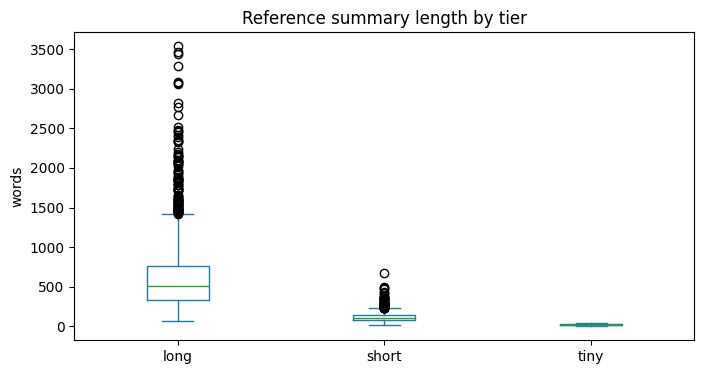

In [8]:
summ_words = pd.DataFrame({
    t.split("_")[1]: DF[t].fillna("").str.split().apply(len).replace(0, np.nan)
    for t in ["summary_long","summary_short","summary_tiny"]})
summ_words.plot.box(figsize=(8,4)); plt.ylabel("words"); plt.title("Reference summary length by tier"); plt.show()

## 5. Cross-tab: case type vs class action
Some case types (e.g. Equal Employment, Prison/Jail Conditions) are much more likely to be brought as class actions — useful signal.

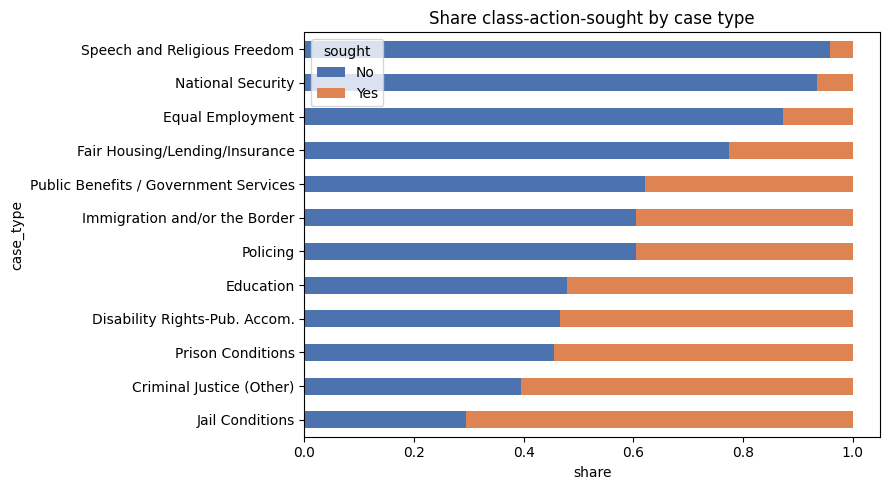

class_action_sought,No,Yes
case_type,,
Jail Conditions,0.29,0.71
Criminal Justice (Other),0.39,0.61
Prison Conditions,0.46,0.54
Disability Rights-Pub. Accom.,0.47,0.53
Education,0.48,0.52
Policing,0.61,0.39
Immigration and/or the Border,0.61,0.39
Public Benefits / Government Services,0.62,0.38
Fair Housing/Lending/Insurance,0.78,0.22


In [9]:
ct = pd.crosstab(DF.case_type, DF.class_action_sought, normalize="index")
ct = ct.sort_values("Yes", ascending=False)
ct.plot.barh(stacked=True, figsize=(9,5), color=["#4C72B0","#DD8452","#999"])
plt.title("Share class-action-sought by case type"); plt.xlabel("share"); plt.legend(title="sought"); plt.tight_layout(); plt.show()
ct.round(2)

## 6. A peek at the raw vs cleaned text
The raw documents carry court page-headers, form-feeds, OCR noise and broken unicode. `src/clean.py` strips the structural boilerplate and repairs the unicode (OCR typos are inherent to the scanned source).

In [10]:
from clean import clean_case_text
row = DF.iloc[0]
print("RAW  :", row.full_text_raw[:500].replace(chr(10)," "))
print("\nCLEAN:", row.full_text_clean[:500].replace(chr(10)," "))

RAW  : Case 1:11-cv-07562-WHP Document 1 Filed 10/26/11 Page 1 of 11  0 UNITED STATES DISTRIC  RT  % SOUTHERN DISTRICT OF NEW  AMERICAN CIVIL LIBERTIES UNION 125 Broad Street New Yorl&, NY 10004,  AMERICAN CIVII. LIBERTIES UNION  FOUNDATION  125 Broad Street  Ncw York, NY 10004,  No.  Plaintiffs,  FFDFRAL BUREAU OF INVESTIC'ATlON, 170 Marcel Drive Winchester, VA 22602 UNITED STATES DEPARTMENT Ol JUSTICE, 1425 New York Avenue, N. W. Washington, D.C. 20530 Dcfcndants.  COlVIPI. AINT FOR INJUNCTIVE RKI, I

CLEAN: 0 UNITED STATES DISTRIC  RT  % SOUTHERN DISTRICT OF NEW  AMERICAN CIVIL LIBERTIES UNION 125 Broad Street New Yorl&, NY 10004,  AMERICAN CIVII. LIBERTIES UNION  FOUNDATION  125 Broad Street  Ncw York, NY 10004,  No.  Plaintiffs,  FFDFRAL BUREAU OF INVESTIC'ATlON, 170 Marcel Drive Winchester, VA 22602 UNITED STATES DEPARTMENT Ol JUSTICE, 1425 New York Avenue, N. W. Washington, D.C. 20530 Dcfcndants.  COlVIPI. AINT FOR INJUNCTIVE RKI, IKF 1. Thiiss i's an action under the Freedom of

### Key findings
* 1,915 cases, 12 case types, official train/dev/test preserved.
* Binary target `class_action_sought` is ~38% *Yes* (imbalanced).
* `case_type` is multi-class; Equal Employment is the largest type.
* Documents are very long (median ~100k chars) and noisy → cleaning + extractive summarisation are essential.
* Reference summaries form a clear long ≫ short ≫ tiny length hierarchy.